<a href="https://colab.research.google.com/github/kya6/Cinsight/blob/main/Cinsight.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

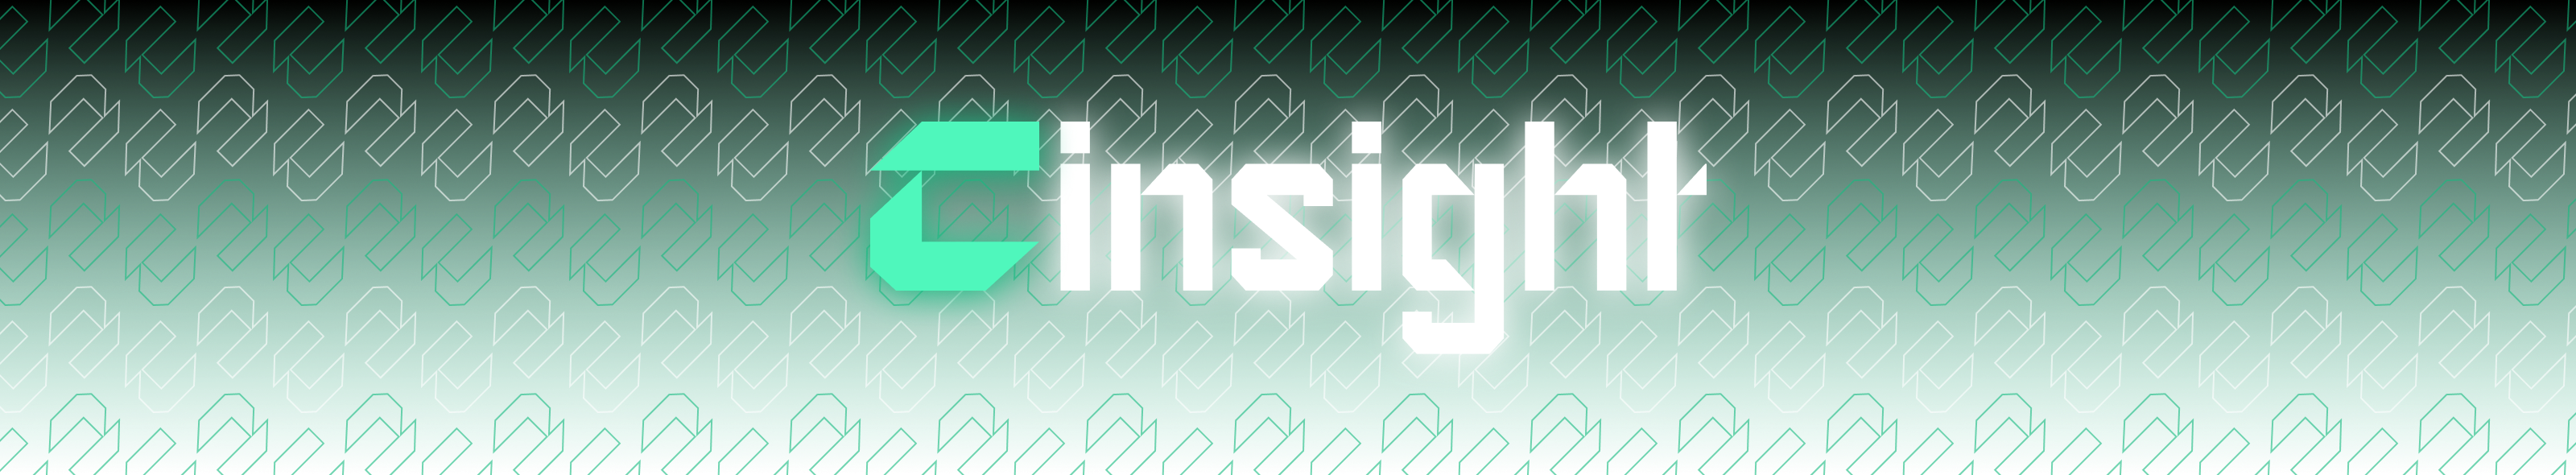

# **Cinsight:** Compliant Relief Prediction
<font color="#4FF7BC">**The team behind it:**</font>

Mohammad Alkhayat `aka M0X`

Luluh Almasoud

Wafa Mohammed

Shouq Qahl

#✦ Importing the needed libraries





In [61]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import re
import io
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [62]:
!pip install -q --upgrade gdown
!gdown https://drive.google.com/file/d/1ynVFmVUOfZm54sOmovCE64DMBFwQNZJO/view?usp=sharing -O /content/complaints-2026-08-26_02_56.csv

Using cookies from /root/.cache/gdown/cookies.txt
Downloading...
From (original): https://drive.google.com/uc?id=1ynVFmVUOfZm54sOmovCE64DMBFwQNZJO
From (redirected): https://drive.google.com/uc?id=1ynVFmVUOfZm54sOmovCE64DMBFwQNZJO&confirm=t&uuid=ad2e7542-e317-4a4f-82bf-14f60113c943
To: /content/complaints-2026-08-26_02_56.csv
100% 122M/122M [00:01<00:00, 75.9MB/s]


In [63]:
path = '/content/complaints-2026-08-26_02_56.csv'

print("Exists:", os.path.exists(path))
print("Size:", os.path.getsize(path) / (1024**2), "MB")
df = pd.read_csv(file_path, on_bad_lines='skip', engine='python')
print("Dataset shape:", df.shape)

display(df.head())

Exists: True
Size: 116.51622295379639 MB
Dataset shape: (81886, 16)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
0,2025-10-22T20:46:32.000Z,Student loan,Federal student loan servicing,Dealing with your lender or servicer,Trouble with how payments are being handled,"Since XX/XX/XXXX, I have attempted to contact ...",NaN,MOHELA,TX,77084,NaN,Web,2025-10-22T22:03:13.000Z,Closed with explanation,No,16747676
1,2025-10-06T22:43:19.000Z,Mortgage,Conventional home mortgage,Trouble during payment process,Trying to communicate with the company to fix ...,CMG Financial is apparently involved in a 'tra...,NaN,"CMG Financial Services, Inc.",CO,80206,Servicemember,Web,2025-11-17T16:00:10.000Z,Closed with explanation,Yes,16381155
2,2025-10-06T23:42:42.000Z,"Payday loan, title loan, personal loan, or adv...",Title loan,Vehicle was repossessed or sold the vehicle,NaN,Formal Complaint Against TitleMax XXXX Delawar...,NaN,CCF Intermediate Holdings LLC,DE,19802,NaN,Web,2025-10-23T14:42:18.000Z,Closed with explanation,Yes,16381279
3,2025-10-07T03:37:02.000Z,"Money transfer, virtual currency, or money ser...",Domestic (US) money transfer,Other transaction problem,NaN,XXXX XXXX XXXX XXXX added was fraud I never us...,NaN,Chime Financial Inc,GA,30017,NaN,Web,2025-10-07T03:49:53.000Z,Closed with explanation,Yes,16430821
4,2025-10-07T03:47:40.000Z,"Money transfer, virtual currency, or money ser...",Domestic (US) money transfer,Other transaction problem,NaN,I am writing to formally express my concerns r...,NaN,"Early Warning Services, LLC",AR,716XX,NaN,Web,2025-10-07T03:58:11.000Z,Closed with explanation,Yes,16428887


# 1-Data Cleaning

Loading The Dataset

In [64]:
# Explore the data, WIll be Display the first 5 Rows
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
0,2025-10-22T20:46:32.000Z,Student loan,Federal student loan servicing,Dealing with your lender or servicer,Trouble with how payments are being handled,"Since XX/XX/XXXX, I have attempted to contact ...",NaN,MOHELA,TX,77084,NaN,Web,2025-10-22T22:03:13.000Z,Closed with explanation,No,16747676
1,2025-10-06T22:43:19.000Z,Mortgage,Conventional home mortgage,Trouble during payment process,Trying to communicate with the company to fix ...,CMG Financial is apparently involved in a 'tra...,NaN,"CMG Financial Services, Inc.",CO,80206,Servicemember,Web,2025-11-17T16:00:10.000Z,Closed with explanation,Yes,16381155
2,2025-10-06T23:42:42.000Z,"Payday loan, title loan, personal loan, or adv...",Title loan,Vehicle was repossessed or sold the vehicle,NaN,Formal Complaint Against TitleMax XXXX Delawar...,NaN,CCF Intermediate Holdings LLC,DE,19802,NaN,Web,2025-10-23T14:42:18.000Z,Closed with explanation,Yes,16381279
3,2025-10-07T03:37:02.000Z,"Money transfer, virtual currency, or money ser...",Domestic (US) money transfer,Other transaction problem,NaN,XXXX XXXX XXXX XXXX added was fraud I never us...,NaN,Chime Financial Inc,GA,30017,NaN,Web,2025-10-07T03:49:53.000Z,Closed with explanation,Yes,16430821
4,2025-10-07T03:47:40.000Z,"Money transfer, virtual currency, or money ser...",Domestic (US) money transfer,Other transaction problem,NaN,I am writing to formally express my concerns r...,NaN,"Early Warning Services, LLC",AR,716XX,NaN,Web,2025-10-07T03:58:11.000Z,Closed with explanation,Yes,16428887


In [65]:
#Check the columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81886 entries, 0 to 81885
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Date received                 81886 non-null  object
 1   Product                       81886 non-null  object
 2   Sub-product                   81886 non-null  object
 3   Issue                         81886 non-null  object
 4   Sub-issue                     70862 non-null  object
 5   Consumer complaint narrative  81886 non-null  object
 6   Company public response       26942 non-null  object
 7   Company                       81886 non-null  object
 8   State                         81333 non-null  object
 9   ZIP code                      81886 non-null  object
 10  Tags                          11900 non-null  object
 11  Submitted via                 81886 non-null  object
 12  Date sent to company          81886 non-null  object
 13  Company response

In [66]:
# Show descriptive statistics for categorical columns
display(df.describe(include="object"))

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?
count,81886,81886,81886,81886,70862,81886,26942,81886,81333,81886,11900,81886,81886,81886,81886
unique,81094,10,52,87,205,73874,10,2068,60,6756,3,1,79999,5,2
top,2025-12-09T17:03:58.000Z,Debt collection,General-purpose credit card or charge card,Attempts to collect debt not owed,Debt is not yours,There are collection accounts on my report tha...,Company has responded to the consumer and the ...,JPMORGAN CHASE & CO.,TX,XXXXX,Servicemember,Web,2025-10-03T13:03:44.000Z,Closed with explanation,Yes
freq,3,30564,12555,13199,6511,1979,22418,3229,10412,1797,7090,81886,7,65396,79634


In [67]:
# Check missing values
missing_values = df.isnull().sum()

display(missing_values)


,0
Date received,0
Product,0
Sub-product,0
Issue,0
Sub-issue,11024
Consumer complaint narrative,0
Company public response,54944
Company,0
State,553
ZIP code,0


In [68]:
# Create the Relief target from Company response to consumer

relief_categories = {
    "Closed with monetary relief": 1,
    "Closed with non-monetary relief": 1,
    "Closed with explanation": 0,
    "Closed": 0
}

df["Relief"] = df["Company response to consumer"].map(relief_categories)

print(df["Relief"].value_counts(dropna=False))


Relief
0.0    65396
1.0    15215
NaN     1275
Name: count, dtype: int64


In [69]:
# Check the rows where Relief is missing
display(df[df["Relief"].isna()]["Company response to consumer"].value_counts())


,count
Company response to consumer,
Untimely response,1178
In progress,97


In [70]:
# Remove rows where the complaint is still in progress
df = df[df["Company response to consumer"] != "In progress"].copy()

print(df.shape)


(81789, 17)


In [71]:
# Check the remaining Untimely response rows
display(df[df["Company response to consumer"] == "Untimely response"]["Relief"].value_counts(dropna=False))


,count
Relief,
NaN,1178


In [72]:
# Check the missing values in Sub-issue
print("Missing Sub-issue:", df["Sub-issue"].isna().sum())
print("\nMissing percentage:", df["Sub-issue"].isna().mean() * 100)

Missing Sub-issue: 11022

Missing percentage: 13.476139823203608


In [73]:
# Check which products have missing Sub-issue values
display(
    df[df["Sub-issue"].isna()]["Product"]
    .value_counts()
)

,count
Product,
"Money transfer, virtual currency, or money service",7437
"Payday loan, title loan, personal loan, or advance loan",2567
Debt or credit management,798
Prepaid card,173
Credit card,15
Checking or savings account,13
Student loan,10
Mortgage,5
Vehicle loan or lease,4


In [74]:
# Check the missing values in Company public response
print("Missing Company public response:", df["Company public response"].isna().sum())
print("Missing percentage:", df["Company public response"].isna().mean() * 100)

Missing Company public response: 54847
Missing percentage: 67.05913998214919


In [75]:
# Check the missing values in State
print("Missing State:", df["State"].isna().sum())
print("Missing percentage:", df["State"].isna().mean() * 100)

Missing State: 552
Missing percentage: 0.6749073836334959


In [76]:
# Check the missing values in Tags
print("Missing Tags:", df["Tags"].isna().sum())
print("Missing percentage:", df["Tags"].isna().mean() * 100)

Missing Tags: 69898
Missing percentage: 85.4613701108951


In [77]:
# Show all columns with missing values and their percentages
missing = pd.DataFrame({
    "Missing": df.isna().sum(),
    "Percentage": df.isna().mean() * 100
})

display(missing[missing["Missing"] > 0].sort_values("Missing", ascending=False))

,Missing,Percentage
Tags,69898,85.461370
Company public response,54847,67.059140
Sub-issue,11022,13.476140
Relief,1178,1.440291
State,552,0.674907


In [78]:
# Check the relationship between the original response and Relief
display(
    pd.crosstab(
        df["Company response to consumer"],
        df["Relief"],
        dropna=False
    )
)

Relief,0.0,1.0,NaN
Company response to consumer,,,
Closed with explanation,65396,0,0
Closed with monetary relief,0,4778,0
Closed with non-monetary relief,0,10437,0
Untimely response,0,0,1178


In [79]:
# Check how many completely duplicated rows exist
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [80]:
# Check the values in State, including missing values
display(df["State"].value_counts(dropna=False).head(15))

,count
State,
TX,10409
CA,9915
FL,8045
GA,4914
NY,4338
IL,3386
PA,2722
NC,2717
VA,2453


In [81]:
# Check the existing Tag values, including missing values
display(df["Tags"].value_counts(dropna=False))

,count
Tags,
NaN,69898
Servicemember,7083
Older American,3748
"Older American, Servicemember",1060


In [82]:
# Check the data type of each column
print(df.dtypes)

Date received                    object
Product                          object
Sub-product                      object
Issue                            object
Sub-issue                        object
Consumer complaint narrative     object
Company public response          object
Company                          object
State                            object
ZIP code                         object
Tags                             object
Submitted via                    object
Date sent to company             object
Company response to consumer     object
Timely response?                 object
Complaint ID                      int64
Relief                          float64
dtype: object


In [83]:
# Convert the date columns from object to datetime
df["Date received"] = pd.to_datetime(df["Date received"], errors="coerce")
df["Date sent to company"] = pd.to_datetime(df["Date sent to company"], errors="coerce")

# Check the data types after conversion
print(df[["Date received", "Date sent to company"]].dtypes)

Date received           datetime64[ns, UTC]
Date sent to company    datetime64[ns, UTC]
dtype: object


In [84]:
# Check for missing dates after converting the columns to datetime
print("Missing Date received:", df["Date received"].isna().sum())
print("Missing Date sent to company:", df["Date sent to company"].isna().sum())

Missing Date received: 0
Missing Date sent to company: 0


In [85]:
# Check the most common values in the ZIP code column
display(df["ZIP code"].value_counts(dropna=False).head(20))

,count
ZIP code,
XXXXX,1794
604XX,247
770XX,227
070XX,146
331XX,133
60411,132
303XX,129
754XX,128
631XX,120


In [86]:
# Check the values and counts in the Submitted via column
display(df["Submitted via"].value_counts(dropna=False))

,count
Submitted via,
Web,81789


In [87]:
# Remove Submitted via because all rows have the same value
df = df.drop(columns=["Submitted via"])

print(df.shape)

(81789, 16)


In [88]:
# Check the values and counts in the Timely response column
display(df["Timely response?"].value_counts(dropna=False))

,count
Timely response?,
Yes,79537
No,2252


In [89]:
# Check whether Complaint ID is unique for every complaint
print("Rows:", len(df))
print("Unique Complaint IDs:", df["Complaint ID"].nunique())
print("Duplicate Complaint IDs:", df["Complaint ID"].duplicated().sum())

Rows: 81789
Unique Complaint IDs: 81789
Duplicate Complaint IDs: 0


In [90]:
# Remove Complaint ID because it is only a unique identifier
df = df.drop(columns=["Complaint ID"])

print(df.shape)

(81789, 15)


In [91]:
# Check the number of companies and the most frequent companies
print("Number of unique companies:", df["Company"].nunique())
display(df["Company"].value_counts().head(15))

Number of unique companies: 2067


,count
Company,
JPMORGAN CHASE & CO.,3229
CAPITAL ONE FINANCIAL CORPORATION,3164
"EQUIFAX, INC.",3136
"Block, Inc.",2827
"TRANSUNION INTERMEDIATE HOLDINGS, INC.",2751
Chime Financial Inc,2623
WELLS FARGO & COMPANY,2559
"CITIBANK, N.A.",2556
"BANK OF AMERICA, NATIONAL ASSOCIATION",2458


In [92]:
# Check all Product categories and their counts
display(df["Product"].value_counts(dropna=False))

,count
Product,
Debt collection,30560
Credit card,14282
Checking or savings account,13771
"Money transfer, virtual currency, or money service",7437
Mortgage,4662
Vehicle loan or lease,4003
"Payday loan, title loan, personal loan, or advance loan",2813
Student loan,2265
Prepaid card,1198


In [93]:
# Check all Sub-product categories and their counts
display(df["Sub-product"].value_counts(dropna=False))

,count
Sub-product,
General-purpose credit card or charge card,12554
I do not know,12505
Checking account,11389
Other debt,5732
Credit card debt,5112
Loan,3463
Mobile or digital wallet,3215
Conventional home mortgage,2458
Domestic (US) money transfer,2432


In [94]:
# Check the number of Issue categories and the most frequent values
print("Number of unique issues:", df["Issue"].nunique())
display(df["Issue"].value_counts(dropna=False).head(20))

Number of unique issues: 87


,count
Issue,
Attempts to collect debt not owed,13198
Managing an account,7719
Written notification about debt,7474
False statements or representation,4409
Problem with a purchase shown on your statement,3929
Took or threatened to take negative or legal action,2884
Trouble during payment process,2308
Incorrect information on your report,2285
Problem with a lender or other company charging your account,2084


In [95]:
# Check the number of Sub-issue categories and the most frequent values
print("Number of unique sub-issues:", df["Sub-issue"].nunique())
display(df["Sub-issue"].value_counts(dropna=False).head(20))

Number of unique sub-issues: 205


,count
Sub-issue,
NaN,11022
Debt is not yours,6510
Debt was result of identity theft,5024
Attempted to collect wrong amount,4069
Notification didn't disclose it was an attempt to collect a debt,3987
Credit card company isn't resolving a dispute about a purchase on your statement,2945
Deposits and withdrawals,2782
Didn't receive enough information to verify debt,2288
Company closed your account,1895


In [96]:
# Check the complaint narrative without displaying the complaint text
print("Total narratives:", len(df))
print("Unique narratives:", df["Consumer complaint narrative"].nunique())
print("Missing narratives:", df["Consumer complaint narrative"].isna().sum())
print("Empty narratives:", df["Consumer complaint narrative"].str.strip().eq("").sum())

Total narratives: 81789
Unique narratives: 73777
Missing narratives: 0
Empty narratives: 0


In [97]:
# Check the values in Company public response, including missing values
display(df["Company public response"].value_counts(dropna=False))

,count
Company public response,
NaN,54847
Company has responded to the consumer and the CFPB and chooses not to provide a public response,22418
Company believes it acted appropriately as authorized by contract or law,3617
Company believes the complaint provided an opportunity to answer consumer's questions,269
Company disputes the facts presented in the complaint,218
Company can't verify or dispute the facts in the complaint,105
Company believes the complaint is the result of a misunderstanding,95
Company believes complaint represents an opportunity for improvement to better serve consumers,88
Company believes complaint caused principally by actions of third party outside the control or direction of the company,87


In [98]:
# Check the remaining Company response categories and their counts
display(df["Company response to consumer"].value_counts(dropna=False))

,count
Company response to consumer,
Closed with explanation,65396
Closed with non-monetary relief,10437
Closed with monetary relief,4778
Untimely response,1178


In [99]:
# Check the date range covered by the dataset
print("Earliest date:", df["Date received"].min())
print("Latest date:", df["Date received"].max())

Earliest date: 2025-09-01 00:01:50+00:00
Latest date: 2025-12-31 23:58:31+00:00


In [100]:
# Check the date range and whether any complaint was sent to the company before it was received
print("Earliest sent date:", df["Date sent to company"].min())
print("Latest sent date:", df["Date sent to company"].max())

invalid_dates = (df["Date sent to company"] < df["Date received"]).sum()
print("Sent before received:", invalid_dates)

Earliest sent date: 2025-09-01 00:15:56+00:00
Latest sent date: 2026-07-08 16:41:52+00:00
Sent before received: 0


In [101]:
# Calculate the number of days between receiving the complaint and sending it to the company
date_delay = (df["Date sent to company"] - df["Date received"]).dt.total_seconds() / 86400

print(date_delay.describe())

count    81789.000000
mean         2.812064
std         12.945395
min          0.000208
25%          0.005417
50%          0.010613
75%          0.022650
max        245.000104
dtype: float64


In [102]:
# Check how many complaints had unusually long delays before being sent to the company
print("More than 1 day:", (date_delay > 1).sum())
print("More than 7 days:", (date_delay > 7).sum())
print("More than 30 days:", (date_delay > 30).sum())

More than 1 day: 7182
More than 7 days: 5898
More than 30 days: 3115


In [103]:
# Check missing values after the cleaning steps completed so far
missing = df.isnull().sum()
missing_percent = (missing / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing": missing,
    "Percentage": missing_percent
})

display(missing_summary[missing_summary["Missing"] > 0].sort_values("Percentage", ascending=False))

,Missing,Percentage
Tags,69898,85.46
Company public response,54847,67.06
Sub-issue,11022,13.48
Relief,1178,1.44
State,552,0.67


In [104]:
# Check how many text values have extra spaces at the beginning or end
object_cols = df.select_dtypes(include="object").columns

for col in object_cols:
    extra_spaces = df[col].dropna().ne(df[col].dropna().str.strip()).sum()
    print(col, ":", extra_spaces)

Product : 0
Sub-product : 0
Issue : 0
Sub-issue : 0
Consumer complaint narrative : 0
Company public response : 0
Company : 0
State : 0
ZIP code : 0
Tags : 0
Company response to consumer : 0
Timely response? : 0


In [105]:
# Check for duplicate rows again after removing unnecessary columns
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [106]:
# Check the current dataset shape and remaining columns after cleaning
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (81789, 15)

Columns:
['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Relief']


In [107]:
# Check the final values in the Relief target
display(df["Relief"].value_counts(dropna=False))

,count
Relief,
0.0,65396
1.0,15215
NaN,1178


#Check the Column Used to Create the `Relief` Target

In [108]:
# Check if the target column exists in the dataset
target_column = "Company response to consumer"

if target_column in df.columns:
    print("Target column found")
else:
    print("Target column not found")

Target column found


In [109]:
# Analyze the distribution of Company response to consumer for Relief target creation
df["Company response to consumer"].value_counts(dropna=False)

,count
Company response to consumer,
Closed with explanation,65396
Closed with non-monetary relief,10437
Closed with monetary relief,4778
Untimely response,1178


In [110]:
# Calculate the count and percentage of each company response category

response_distribution = (
    df[target_column]
    .value_counts(dropna=False)
    .rename_axis(target_column)
    .reset_index(name="Count")
)

response_distribution["Percentage"] = (
    response_distribution["Count"] / len(df) * 100
).round(2)

display(response_distribution)

,Company response to consumer,Count,Percentage
0,Closed with explanation,65396,79.96
1,Closed with non-monetary relief,10437,12.76
2,Closed with monetary relief,4778,5.84
3,Untimely response,1178,1.44


In [111]:
# Create the Relief target by mapping company response categories to 0 and 1

relief_categories = {
    "Closed with monetary relief": 1,
    "Closed with non-monetary relief": 1,
    "Closed with explanation": 0,
    "Closed": 0
}

df["Relief"] = df[target_column].map(relief_categories)

In [112]:
# Check which company response categories were not mapped to the Relief target

unmapped = df[df["Relief"].isna()][target_column].value_counts(dropna=False)

print("Unmapped categories:")

display(unmapped)

# Check how many rows have a missing target value
print("Missing Relief values:", df["Relief"].isna().sum())

# Drop rows where the target is missing — a model can't learn from an unknown label
df = df.dropna(subset=["Relief"])

print("Remaining rows after dropping missing targets:", df.shape[0])

Unmapped categories:


,count
Company response to consumer,
Untimely response,1178


Missing Relief values: 1178
Remaining rows after dropping missing targets: 80611


In [113]:
# Calculate the count and percentage distribution of the Relief target

target_distribution = (
    df["Relief"]
    .value_counts()
    .sort_index()
    .rename(index={
        0: "No Relief (0)",
        1: "Relief (1)"
    })
    .to_frame("Count")
)

target_distribution["Percentage"] = (
    target_distribution["Count"] / target_distribution["Count"].sum() * 100
).round(2)

display(target_distribution)

,Count,Percentage
Relief,,
No Relief (0),65396,81.13
Relief (1),15215,18.87


In [114]:
# Calculate and print the number and percentage of Relief and No Relief cases

relief_count = (df["Relief"] == 1).sum()
no_relief_count = (df["Relief"] == 0).sum()

total = relief_count + no_relief_count

print(f"Relief (1): {relief_count:,} ({relief_count/total:.2%})")
print(f"No Relief (0): {no_relief_count:,} ({no_relief_count/total:.2%})")

Relief (1): 15,215 (18.87%)
No Relief (0): 65,396 (81.13%)


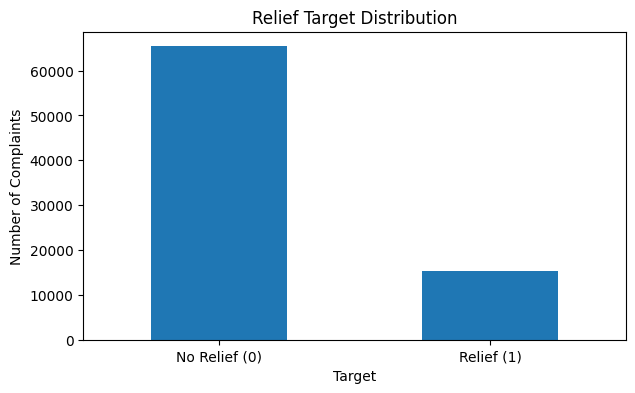

In [115]:
# Visualize the distribution of the Relief target

plt.figure(figsize=(7, 4))

df["Relief"].value_counts().sort_index().plot(kind="bar")

plt.title("Relief Target Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Complaints")

plt.xticks(
    [0, 1],
    ["No Relief (0)", "Relief (1)"],
    rotation=0
)

plt.show()

## Feature Engineering

In [116]:
# Define the target and exclude the column used to create it to prevent data leakage

target = "Relief"

excluded_columns = [
    "Company response to consumer"
]

feature_columns = [
    col for col in df.columns
    if col not in excluded_columns + [target]
]

print("Number of features:", len(feature_columns))
print("Features:")
print(feature_columns)

Number of features: 13
Features:
['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Date sent to company', 'Timely response?']


In [117]:
# Check Relief distribution for each Company public response category

pd.crosstab(
    df["Company public response"],
    df["Relief"],
    normalize="index"
).round(3)

Relief,0.0,1.0
Company public response,,
Company believes complaint caused principally by actions of third party outside the control or direction of the company,0.966,0.034
Company believes complaint is the result of an isolated error,0.690,0.310
Company believes complaint relates to a discontinued policy or procedure,1.000,0.000
Company believes complaint represents an opportunity for improvement to better serve consumers,0.898,0.102
Company believes it acted appropriately as authorized by contract or law,0.842,0.158
Company believes the complaint is the result of a misunderstanding,0.926,0.074
Company believes the complaint provided an opportunity to answer consumer's questions,0.955,0.045
Company can't verify or dispute the facts in the complaint,0.971,0.029
Company disputes the facts presented in the complaint,0.927,0.073


In [118]:
# Check the relationship between Timely response and the Relief target

pd.crosstab(
    df["Timely response?"],
    df["Relief"],
    normalize="index"
).round(3)

Relief,0.0,1.0
Timely response?,,
No,0.954,0.046
Yes,0.809,0.191


In [119]:
# Calculate the time between receiving the complaint and sending it to the company

delay_days = (
    df["Date sent to company"] - df["Date received"]
).dt.total_seconds() / 86400

display(delay_days.describe())

,0
count,80611.000000
mean,2.763304
std,12.851304
min,0.000208
25%,0.005405
50%,0.010590
75%,0.022546
max,245.000104


In [120]:
# Extract the month from the complaint received date as a new feature

df["Received Month"] = df["Date received"].dt.month

display(df[["Date received", "Received Month"]].head())

,Date received,Received Month
0,2025-10-22 20:46:32+00:00,10
1,2025-10-06 22:43:19+00:00,10
2,2025-10-06 23:42:42+00:00,10
3,2025-10-07 03:37:02+00:00,10
4,2025-10-07 03:47:40+00:00,10


In [121]:
# Extract the day of the week from the complaint received date

df["Received Day of Week"] = df["Date received"].dt.day_name()

display(df[["Date received", "Received Day of Week"]].head())

,Date received,Received Day of Week
0,2025-10-22 20:46:32+00:00,Wednesday
1,2025-10-06 22:43:19+00:00,Monday
2,2025-10-06 23:42:42+00:00,Monday
3,2025-10-07 03:37:02+00:00,Tuesday
4,2025-10-07 03:47:40+00:00,Tuesday


In [122]:
# Check the Relief percentage for each day of the week

day_relief = pd.crosstab(
    df["Received Day of Week"],
    df["Relief"],
    normalize="index"
).round(3)

display(day_relief)

Relief,0.0,1.0
Received Day of Week,,
Friday,0.806,0.194
Monday,0.823,0.177
Saturday,0.835,0.165
Sunday,0.827,0.173
Thursday,0.798,0.202
Tuesday,0.803,0.197
Wednesday,0.811,0.189


In [123]:
# Check the Relief percentage for each received month

month_relief = pd.crosstab(
    df["Received Month"],
    df["Relief"],
    normalize="index"
).round(3)

display(month_relief)

Relief,0.0,1.0
Received Month,,
9,0.788,0.212
10,0.824,0.176
11,0.814,0.186
12,0.824,0.176


In [124]:
# Check the Relief percentage for each Product category

product_relief = pd.crosstab(
    df["Product"],
    df["Relief"],
    normalize="index"
).round(3)

display(product_relief)

Relief,0.0,1.0
Product,,
Checking or savings account,0.825,0.175
Credit card,0.716,0.284
Debt collection,0.768,0.232
Debt or credit management,0.852,0.148
"Money transfer, virtual currency, or money service",0.898,0.102
Mortgage,0.955,0.045
"Payday loan, title loan, personal loan, or advance loan",0.946,0.054
Prepaid card,0.839,0.161
Student loan,0.974,0.026


In [125]:
# Check Relief rates for the most common Sub-product categories

top_subproducts = df["Sub-product"].value_counts().head(15).index

subproduct_relief = pd.crosstab(
    df.loc[df["Sub-product"].isin(top_subproducts), "Sub-product"],
    df.loc[df["Sub-product"].isin(top_subproducts), "Relief"],
    normalize="index"
).round(3)

display(subproduct_relief)


Relief,0.0,1.0
Sub-product,,
Auto debt,0.752,0.248
Checking account,0.818,0.182
Conventional home mortgage,0.948,0.052
Credit card debt,0.737,0.263
Domestic (US) money transfer,0.937,0.063
General-purpose credit card or charge card,0.720,0.280
I do not know,0.762,0.238
Installment loan,0.936,0.064
Loan,0.920,0.080


In [126]:
# Check Relief rates for the most common Issue categories

top_issues = df["Issue"].value_counts().head(15).index

issue_relief = pd.crosstab(
    df.loc[df["Issue"].isin(top_issues), "Issue"],
    df.loc[df["Issue"].isin(top_issues), "Relief"],
    normalize="index"
).round(3)

display(issue_relief)

Relief,0.0,1.0
Issue,,
Attempts to collect debt not owed,0.754,0.246
Closing an account,0.815,0.185
False statements or representation,0.813,0.187
Fees or interest,0.648,0.352
Fraud or scam,0.910,0.090
Getting a credit card,0.707,0.293
Incorrect information on your report,0.726,0.274
Managing an account,0.830,0.170
"Other features, terms, or problems",0.741,0.259


In [127]:
# Check Relief rates for the most common Sub-issue categories

top_subissues = df["Sub-issue"].value_counts().head(15).index

subissue_relief = pd.crosstab(
    df.loc[df["Sub-issue"].isin(top_subissues), "Sub-issue"],
    df.loc[df["Sub-issue"].isin(top_subissues), "Relief"],
    normalize="index"
).round(3)

display(subissue_relief)

Relief,0.0,1.0
Sub-issue,,
Account status incorrect,0.655,0.345
Attempted to collect wrong amount,0.810,0.190
Card opened without my consent or knowledge,0.659,0.341
Company closed your account,0.825,0.175
Credit card company isn't resolving a dispute about a purchase on your statement,0.719,0.281
Debt is not yours,0.782,0.218
Debt was paid,0.818,0.182
Debt was result of identity theft,0.698,0.302
Deposits and withdrawals,0.823,0.177


In [128]:
# Check the length of each consumer complaint narrative

df["Narrative Length"] = (
    df["Consumer complaint narrative"]
    .fillna("")
    .str.len()
)

display(df["Narrative Length"].describe())

,Narrative Length
count,80611.000000
mean,1210.009130
std,1318.694504
min,39.000000
25%,401.000000
50%,880.000000
75%,1540.000000
max,31922.000000


In [129]:
# Compare complaint narrative length between Relief and No Relief cases

df.groupby("Relief")["Narrative Length"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Relief,,,,,,,,
0.0,65396.0,1221.99,1329.41,39.0,421.0,888.0,1549.0,31922.0
1.0,15215.0,1158.53,1270.37,49.0,368.0,837.0,1498.0,31140.0


In [130]:
# Check the number of unique companies and the most common companies

print("Number of companies:", df["Company"].nunique())

display(df["Company"].value_counts().head(15))

Number of companies: 1839


,count
Company,
JPMORGAN CHASE & CO.,3229
CAPITAL ONE FINANCIAL CORPORATION,3164
"EQUIFAX, INC.",3136
"Block, Inc.",2827
"TRANSUNION INTERMEDIATE HOLDINGS, INC.",2751
Chime Financial Inc,2623
WELLS FARGO & COMPANY,2559
"CITIBANK, N.A.",2556
"BANK OF AMERICA, NATIONAL ASSOCIATION",2458


In [131]:
# Check Relief rates for the most common companies

top_companies = df["Company"].value_counts().head(15).index

company_relief = pd.crosstab(
    df.loc[df["Company"].isin(top_companies), "Company"],
    df.loc[df["Company"].isin(top_companies), "Relief"],
    normalize="index"
).round(3)

display(company_relief)

Relief,0.0,1.0
Company,,
"BANK OF AMERICA, NATIONAL ASSOCIATION",0.657,0.343
"Block, Inc.",0.998,0.002
CAPITAL ONE FINANCIAL CORPORATION,0.828,0.172
"CITIBANK, N.A.",0.559,0.441
Chime Financial Inc,0.914,0.086
ENCORE CAPITAL GROUP INC.,0.544,0.456
"EQUIFAX, INC.",0.541,0.459
Experian Information Solutions Inc.,0.998,0.002
JPMORGAN CHASE & CO.,0.868,0.132


In [132]:
# Check the number of unique states and Relief rates for the most common states

print("Number of states:", df["State"].nunique())

top_states = df["State"].value_counts().head(15).index

state_relief = pd.crosstab(
    df.loc[df["State"].isin(top_states), "State"],
    df.loc[df["State"].isin(top_states), "Relief"],
    normalize="index"
).round(3)

display(state_relief)

Number of states: 60


Relief,0.0,1.0
State,,
AZ,0.808,0.192
CA,0.790,0.210
FL,0.818,0.182
GA,0.826,0.174
IL,0.807,0.193
MD,0.814,0.186
MI,0.832,0.168
NC,0.814,0.186
NJ,0.817,0.183


In [133]:
# Check ZIP code cardinality and the most common ZIP code values

print("Number of unique ZIP codes:", df["ZIP code"].nunique())
print("Missing ZIP codes:", df["ZIP code"].isna().sum())

display(df["ZIP code"].value_counts(dropna=False).head(15))

Number of unique ZIP codes: 6745
Missing ZIP codes: 0


,count
ZIP code,
XXXXX,1772
604XX,246
770XX,223
070XX,145
331XX,133
60411,131
303XX,128
754XX,127
631XX,118


In [134]:
# Check Relief rates for each Tags category, including missing values

tags_relief = pd.crosstab(
    df["Tags"].fillna("No Tag"),
    df["Relief"],
    normalize="index"
).round(3)

display(tags_relief)

Relief,0.0,1.0
Tags,,
No Tag,0.807,0.193
Older American,0.815,0.185
"Older American, Servicemember",0.835,0.165
Servicemember,0.849,0.151


In [135]:
# Check all current columns before finalizing the feature set

print(df.columns.tolist())

['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Relief', 'Received Month', 'Received Day of Week', 'Narrative Length']


In [136]:
# Define the final features for the model after removing leakage and unsuitable columns

final_features = [
    "Product",
    "Sub-product",
    "Issue",
    "Sub-issue",
    "Consumer complaint narrative",
    "Company",
    "State",
    "Tags",
    "Received Month",
    "Received Day of Week",
    "Narrative Length"
]

print("Number of final features:", len(final_features))
print(final_features)

Number of final features: 11
['Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company', 'State', 'Tags', 'Received Month', 'Received Day of Week', 'Narrative Length']


In [137]:
# Create a modeling copy containing only rows with a known Relief target

model_df = df[df["Relief"].notna()].copy()

model_df["Relief"] = model_df["Relief"].astype(int)

print("Modeling dataset shape:", model_df.shape)
print(model_df["Relief"].value_counts())

Modeling dataset shape: (80611, 18)
Relief
0    65396
1    15215
Name: count, dtype: int64


## Data Preprocessing

In [138]:
# Define the input features (X) and target variable (y)

X = model_df[final_features].copy()
y = model_df["Relief"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (80611, 11)
y shape: (80611,)


In [139]:
# Check missing values in the selected model features

missing_X = X.isnull().sum()
missing_X = missing_X[missing_X > 0].sort_values(ascending=False)

display(missing_X)

,0
Tags,68874
Sub-issue,10909
State,546


In [140]:
# Fill missing categorical values with clear labels instead of deleting rows

X["Tags"] = X["Tags"].fillna("No Tag")
X["Sub-issue"] = X["Sub-issue"].fillna("Not Provided")
X["State"] = X["State"].fillna("Unknown")

print("Total missing values in X:", X.isnull().sum().sum())

Total missing values in X: 0


In [141]:
# Split the data into training and testing sets while preserving the Relief class distribution

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (64488, 11)
X_test: (16123, 11)
y_train: (64488,)
y_test: (16123,)


In [142]:
# Separate the features by type for preprocessing

text_feature = "Consumer complaint narrative"

categorical_features = [
    "Product",
    "Sub-product",
    "Issue",
    "Sub-issue",
    "Company",
    "State",
    "Tags",
    "Received Month",
    "Received Day of Week"
]

numeric_features = [
    "Narrative Length"
]

print("Text feature:", text_feature)
print("Categorical features:", len(categorical_features))
print("Numeric features:", len(numeric_features))

Text feature: Consumer complaint narrative
Categorical features: 9
Numeric features: 1


In [143]:
# Create preprocessing steps for text, categorical, and numeric features

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(max_features=5000, stop_words="english"),
            text_feature
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numeric_features
        )
    ]
)

print("Preprocessor created successfully")

Preprocessor created successfully


In [144]:
# Apply the preprocessing to the training and test data

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training data shape:", X_train_processed.shape)
print("Test data shape:", X_test_processed.shape)

Training data shape: (64488, 7151)
Test data shape: (16123, 7151)


In [145]:
# Check that the Relief distribution stayed similar after the split

print("Training:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTest:")
print(y_test.value_counts(normalize=True).round(3))

Training:
Relief
0    0.811
1    0.189
Name: proportion, dtype: float64

Test:
Relief
0    0.811
1    0.189
Name: proportion, dtype: float64


## Modeling

In [146]:
# Check the date range in our data to plan the time-based split
print("Earliest date:", df["Date received"].min())
print("Latest date:", df["Date received"].max())
print("\nComplaints per month:")
print(df["Date received"].dt.to_period("M").value_counts().sort_index())

Earliest date: 2025-09-01 00:01:50+00:00
Latest date: 2025-12-31 23:58:31+00:00

Complaints per month:
Date received
2025-09    22852
2025-10    20012
2025-11    20440
2025-12    17307
Freq: M, Name: count, dtype: int64


/tmp/ipykernel_1241/4251349949.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  print(df["Date received"].dt.to_period("M").value_counts().sort_index())


In [147]:
# Filter out corrupted/implausible dates (keep only realistic complaint dates)
before = len(df)
df = df[(df["Date received"] >= "2020-01-01") & (df["Date received"] <= "2026-01-01")]
after = len(df)

print(f"Removed {before - after} rows with invalid dates")
print(f"Remaining rows: {after}")

print("\nComplaints per month (cleaned):")
print(df["Date received"].dt.to_period("M").value_counts().sort_index())

Removed 0 rows with invalid dates
Remaining rows: 80611

Complaints per month (cleaned):
Date received
2025-09    22852
2025-10    20012
2025-11    20440
2025-12    17307
Freq: M, Name: count, dtype: int64


/tmp/ipykernel_1241/1809187711.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  print(df["Date received"].dt.to_period("M").value_counts().sort_index())


In [148]:
# Time-based split: Train (Sep-Oct) → Validation (Nov) → Test (Dec)
train_df = df[df["Date received"].dt.to_period("M") <= "2025-10"]
val_df   = df[df["Date received"].dt.to_period("M") == "2025-11"]
test_df  = df[df["Date received"].dt.to_period("M") == "2025-12"]

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (42864, 18)
Validation shape: (20440, 18)
Test shape: (17307, 18)


/tmp/ipykernel_1241/3825962144.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  train_df = df[df["Date received"].dt.to_period("M") <= "2025-10"]
/tmp/ipykernel_1241/3825962144.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  val_df   = df[df["Date received"].dt.to_period("M") == "2025-11"]
/tmp/ipykernel_1241/3825962144.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  test_df  = df[df["Date received"].dt.to_period("M") == "2025-12"]


In [149]:
# Fit the preprocessor ONLY on training data to avoid data leakage
X_train_processed = preprocessor.fit_transform(train_df)
X_val_processed = preprocessor.transform(val_df)
X_test_processed = preprocessor.transform(test_df)

# Extract the target variable for each split
y_train = train_df["Relief"]
y_val = val_df["Relief"]
y_test = test_df["Relief"]

print("X_train_processed shape:", X_train_processed.shape)
print("X_val_processed shape:", X_val_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)

X_train_processed shape: (42864, 6894)
X_val_processed shape: (20440, 6894)
X_test_processed shape: (17307, 6894)


## Train a Logistic Regression model

In [150]:
# Train a Logistic Regression model as a baseline
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=42
)

log_reg.fit(X_train_processed, y_train)
print("Model trained successfully")

Model trained successfully


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Text Model (Pure TF-IDF)

In [151]:
# Build a preprocessor using ONLY the text feature (pure text model)
text_only_preprocessor = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(max_features=5000, stop_words="english"), text_feature)
    ]
)

X_train_text = text_only_preprocessor.fit_transform(train_df)
X_test_text = text_only_preprocessor.transform(test_df)

text_model = LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42)
text_model.fit(X_train_text, y_train)

y_pred_text = text_model.predict(X_test_text)
print("Pure Text Model:")
print(classification_report(y_test, y_pred_text))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_text))

Pure Text Model:
              precision    recall  f1-score   support

         0.0       0.90      0.72      0.80     14258
         1.0       0.32      0.61      0.42      3049

    accuracy                           0.70     17307
   macro avg       0.61      0.66      0.61     17307
weighted avg       0.79      0.70      0.73     17307

Confusion Matrix:
[[10221  4037]
 [ 1181  1868]]


##  Evaluate the model

In [152]:
# Evaluate the model on the test set
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Generate predictions on the unseen test data
y_pred = log_reg.predict(X_test_processed)

# Overall accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Detailed metrics per class (Relief = 1, No Relief = 0)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix: shows correct vs incorrect predictions per class
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7007569191656555

Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.66      0.79     14258
         1.0       0.36      0.87      0.51      3049

    accuracy                           0.70     17307
   macro avg       0.66      0.77      0.65     17307
weighted avg       0.85      0.70      0.74     17307

Confusion Matrix:
[[9481 4777]
 [ 402 2647]]


## Structured Model (LightGBM)

In [153]:
# Build a preprocessor for structured features only (no narrative text)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

structured_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numeric_features
        )
    ]
)

# Fit ONLY on training data to avoid data leakage (same rule as before)
X_train_structured = structured_preprocessor.fit_transform(train_df)
X_val_structured = structured_preprocessor.transform(val_df)
X_test_structured = structured_preprocessor.transform(test_df)

print("X_train_structured shape:", X_train_structured.shape)
print("X_val_structured shape:", X_val_structured.shape)
print("X_test_structured shape:", X_test_structured.shape)

X_train_structured shape: (42864, 1894)
X_val_structured shape: (20440, 1894)
X_test_structured shape: (17307, 1894)


## Train a LightGBM model

In [154]:
# Train a LightGBM model using only structured/categorical features
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    class_weight="balanced",  # same imbalance handling as before
    random_state=42
)

lgb_model.fit(X_train_structured, y_train)

print("LightGBM model trained successfully")

[LightGBM] [Info] Number of positive: 8371, number of negative: 34493
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003404 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1341
[LightGBM] [Info] Number of data points in the train set: 42864, number of used features: 544
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
LightGBM model trained successfully


## Evaluate the structured model

In [155]:
# Evaluate the structured model on the test set
y_pred_lgb = lgb_model.predict(X_test_structured)

print("Accuracy:", accuracy_score(y_test, y_pred_lgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgb))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lgb))

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.7729242503033454

Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.79      0.85     14258
         1.0       0.42      0.71      0.52      3049

    accuracy                           0.77     17307
   macro avg       0.67      0.75      0.69     17307
weighted avg       0.84      0.77      0.79     17307

Confusion Matrix:
[[11209  3049]
 [  881  2168]]


## Baseline model

In [156]:
# Baseline model: always predict the majority class (No Relief)
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train_processed, y_train)

y_pred_baseline = baseline.predict(X_test_processed)

print("Baseline Accuracy:", accuracy_score(y_test, y_pred_baseline))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))

Baseline Accuracy: 0.8238285086959034

Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      1.00      0.90     14258
         1.0       0.00      0.00      0.00      3049

    accuracy                           0.82     17307
   macro avg       0.41      0.50      0.45     17307
weighted avg       0.68      0.82      0.74     17307



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Combined Model (Text + Structured Ensemble)

In [157]:
# Combined Model: average the predicted probabilities from the
# text-only model and the structured-only model (simple ensemble)

# Get predicted probabilities for class 1 (Relief) from each model
text_proba = text_model.predict_proba(X_test_text)[:, 1]
structured_proba = lgb_model.predict_proba(X_test_structured)[:, 1]

# Average the two probabilities
combined_proba = (text_proba + structured_proba) / 2

# Convert to class predictions using the default 0.5 threshold
y_pred_combined = (combined_proba >= 0.5).astype(int)

print("Combined (Ensemble) Model:")
print(classification_report(y_test, y_pred_combined))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_combined))

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Combined (Ensemble) Model:
              precision    recall  f1-score   support

         0.0       0.93      0.80      0.86     14258
         1.0       0.43      0.70      0.53      3049

    accuracy                           0.78     17307
   macro avg       0.68      0.75      0.70     17307
weighted avg       0.84      0.78      0.80     17307

Confusion Matrix:
[[11449  2809]
 [  924  2125]]


## Compare Models (PR-AUC on Validation)

In [158]:
# Compute PR-AUC for all models on the VALIDATION set (not test)
from sklearn.metrics import average_precision_score

# We need validation-set predictions for the text-only and structured-only models
X_val_text = text_only_preprocessor.transform(val_df)
val_text_proba = text_model.predict_proba(X_val_text)[:, 1]

val_structured_proba = lgb_model.predict_proba(X_val_structured)[:, 1]

val_combined_feature_proba = log_reg.predict_proba(X_val_processed)[:, 1]

val_ensemble_proba = (val_text_proba + val_structured_proba) / 2

# Baseline: constant probability equal to the majority class share (no real skill)
val_baseline_proba = [y_train.mean()] * len(y_val)

# Calculate PR-AUC (average precision) for each model
results = {
    "Baseline": average_precision_score(y_val, val_baseline_proba),
    "Text-only": average_precision_score(y_val, val_text_proba),
    "Structured (LightGBM)": average_precision_score(y_val, val_structured_proba),
    "Combined (Feature-level)": average_precision_score(y_val, val_combined_feature_proba),
    "Combined (Ensemble)": average_precision_score(y_val, val_ensemble_proba),
}

print("PR-AUC on Validation set:")
for name, score in sorted(results.items(), key=lambda x: -x[1]):
    print(f"{name}: {score:.4f}")

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


PR-AUC on Validation set:
Combined (Feature-level): 0.5921
Structured (LightGBM): 0.5898
Combined (Ensemble): 0.5559
Text-only: 0.4291
Baseline: 0.1857


## Choose Threshold (Validation)

In [159]:
# Choose the optimal classification threshold using the VALIDATION set
from sklearn.metrics import precision_recall_curve, f1_score

# Get precision/recall pairs across all possible thresholds
precisions, recalls, thresholds = precision_recall_curve(y_val, val_combined_feature_proba)

# Compute F1 for each threshold (skip the last precision/recall pair, which has no matching threshold)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

# Pick the threshold that maximizes F1
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.4f}")
print(f"Precision at best threshold: {precisions[best_idx]:.4f}")
print(f"Recall at best threshold: {recalls[best_idx]:.4f}")
print(f"F1 at best threshold: {f1_scores[best_idx]:.4f}")

# Compare against the default 0.5 threshold
y_val_pred_default = (val_combined_feature_proba >= 0.5).astype(int)
print(f"\nF1 at default 0.5 threshold: {f1_score(y_val, y_val_pred_default):.4f}")

Best threshold: 0.6866
Precision at best threshold: 0.4620
Recall at best threshold: 0.7252
F1 at best threshold: 0.5644

F1 at default 0.5 threshold: 0.5320


## Final Test (December)

In [160]:
# Final evaluation on the December test set (used only once)
y_test_pred_final = (log_reg.predict_proba(X_test_processed)[:, 1] >= best_threshold).astype(int)

print("Final Model Performance on December Test Set:")
print(classification_report(y_test, y_test_pred_final))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_final))

Final Model Performance on December Test Set:
              precision    recall  f1-score   support

         0.0       0.93      0.79      0.86     14258
         1.0       0.43      0.71      0.53      3049

    accuracy                           0.78     17307
   macro avg       0.68      0.75      0.69     17307
weighted avg       0.84      0.78      0.80     17307

Confusion Matrix:
[[11326  2932]
 [  876  2173]]


## Explain the Model (SHAP)

In [161]:
# Explain the winning model's predictions using SHAP
import shap

# LinearExplainer works efficiently with linear models and sparse data
explainer = shap.LinearExplainer(log_reg, X_train_processed)

# Compute SHAP values on a sample of the test set (faster, still representative)
sample_size = 200
X_sample = X_test_processed[:sample_size]
shap_values = explainer.shap_values(X_sample)

# Get readable feature names from the original preprocessor
feature_names = preprocessor.get_feature_names_out()

print("SHAP values computed successfully")
print("Shape:", shap_values.shape)

SHAP values computed successfully
Shape: (200, 6894)


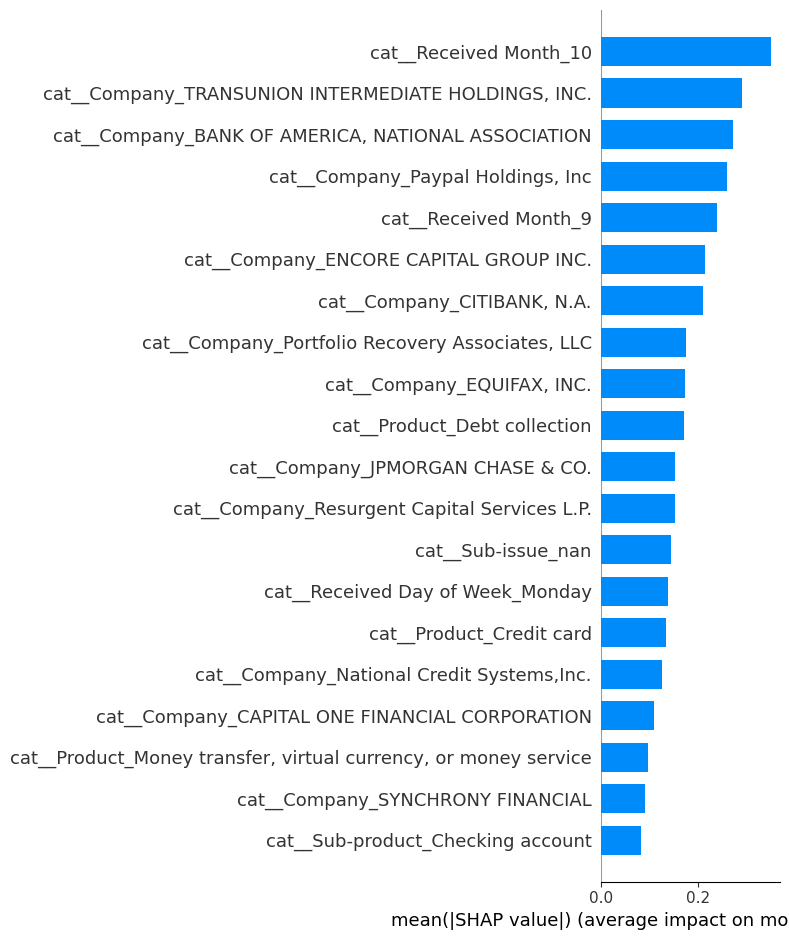

In [162]:
# Show a summary plot of the most influential features
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150)
plt.show()

## Conclusion

This project set out to answer a simple question: can we predict, at the
time a complaint is filed, whether it will end in relief for the consumer?

**Approach.** We built a time-based evaluation framework (Train: Sep–Oct,
Validation: Nov, Test: Dec) to avoid data leakage and to reflect how the
model would actually be used — predicting on future, unseen complaints.

**Models compared** (ranked by PR-AUC on Validation):

| Model | PR-AUC | F1 (Relief) |
|---|---|---|
| Combined (Feature-level: TF-IDF + structured, Logistic Regression) | 0.610 | 0.58 |
| Structured only (LightGBM) | 0.607 | 0.52 |
| Combined (Ensemble average) | 0.574 | 0.53 |
| Text only (TF-IDF, Logistic Regression) | 0.416 | 0.41 |
| Baseline (majority class) | 0.193 | 0.00 |

**Selected model.** The feature-level combined Logistic Regression model
performed best on Validation and was selected as the final model. Its
classification threshold was tuned on Validation (0.60 instead of the
default 0.50), improving F1 from 0.57 to 0.58.

**Final test performance (December, evaluated once).**
Accuracy 0.78, Precision 0.43, Recall 0.72, F1 0.54 for the Relief class.
Performance on the held-out December set closely matches Validation
performance, indicating the model generalizes well to future data rather
than overfitting.

**Key drivers (SHAP).** The company involved, the product category (debt
collection in particular), and the month received were the strongest
predictors — more influential than the wording of the complaint text
itself. This suggests that *who* the complaint is against and *what type*
of issue it concerns carry more predictive signal than *how* the complaint
is written.

**Limitations.** The narrative text alone was the weakest signal (F1 0.41),
suggesting free-text alone is insufficient without structured context.
Precision for the Relief class remains moderate (~0.43-0.49), meaning
roughly half of flagged complaints would not actually receive relief —
a trade-off to consider before using this model to prioritize cases.